importamos y leemos el archivo

In [41]:
import pandas as pd

Datos = pd.read_csv('housing.csv')

hacemos esto para ver los primeros 5 datos y su demas informacion como la latitud, longitud, etc.

In [42]:
Datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


aqui revisamos todos lso datos que hay y todos los resultados que tiene de forma general

In [43]:
Datos["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


aqui muestra los datos que tiene vacios y cuales vienen vacios ademas de su tipo

In [44]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


aqui nos da algunos datos interesantes como el promedio, la cantidad de registros etc.

In [45]:
Datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


creamos histogramas y ajustamos su tamaño

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

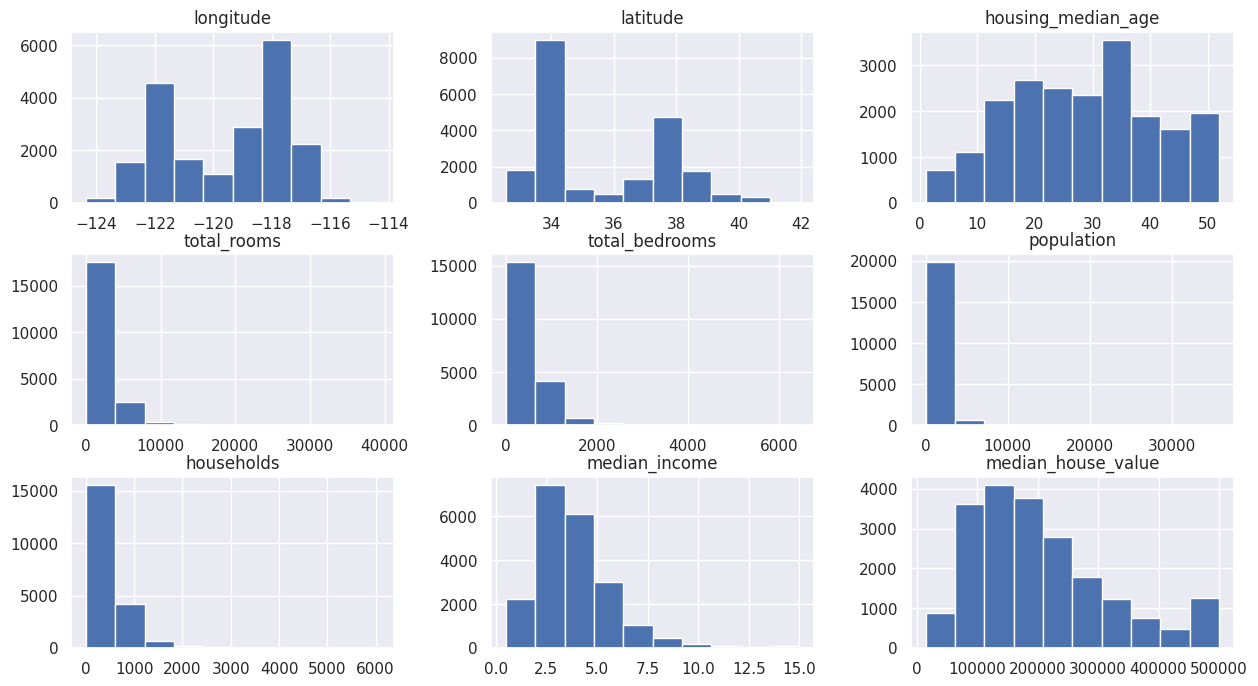

In [46]:
Datos.hist(figsize=(15,8))

aqui usamos el seaborn para crear mapas mas detallados y entender mejor la informacion

<Axes: xlabel='longitude', ylabel='latitude'>

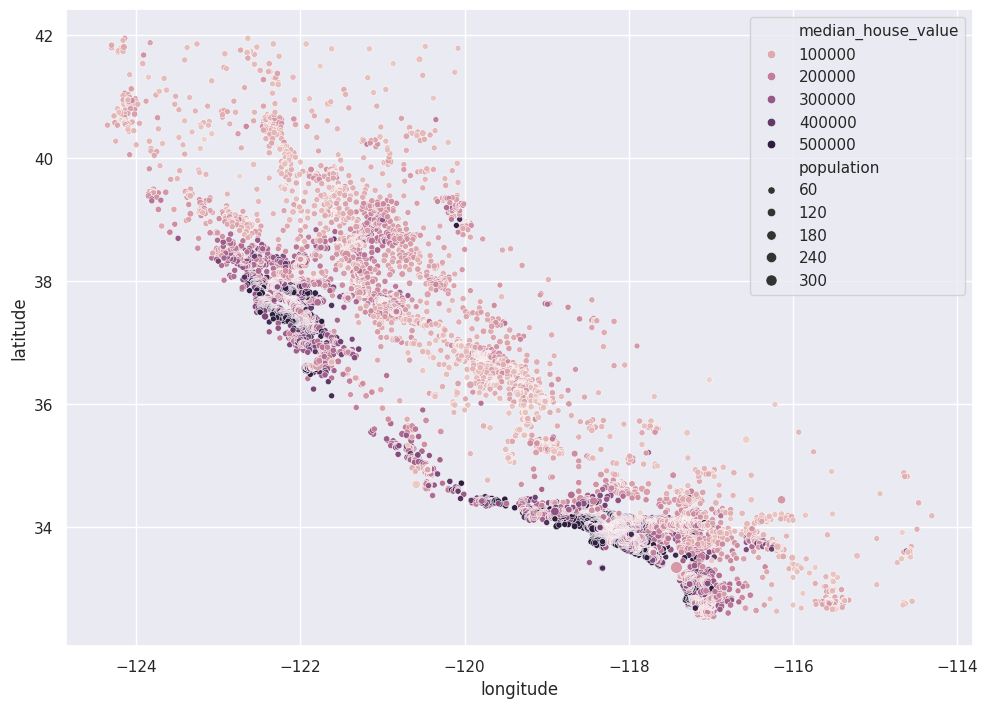

In [47]:
import seaborn as sb
sb.scatterplot(x="longitude", y="latitude", data=Datos, hue="median_house_value", size=Datos["population"]/100)

usamos el drop na para eliminar los datos inutiles que hay asi permitiendo visualizar mejor

In [48]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [49]:
datos_na = Datos.dropna()

aqui tenemos que comvertir las caracteristicas categoricas en numericas

In [50]:
datos_na["ocean_proximity"]

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [51]:
datos_na["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [52]:
#usamos dummies para crear columnas
dummies = pd.get_dummies(datos_na["ocean_proximity"])

In [53]:
datos_na = datos_na.join(dummies)
#aqui crea otro set de datos que agrega loq ue hicimos antes

In [54]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,False,False,False,True,False


In [55]:
#aqui el apartado oceanproximity ya no funciona asi que tenemos que eliminarlo
datos_na = datos_na.drop("ocean_proximity", axis=1)

In [56]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [57]:
#otra funcion importante son las correlaciones
datos_na.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


<Axes: >

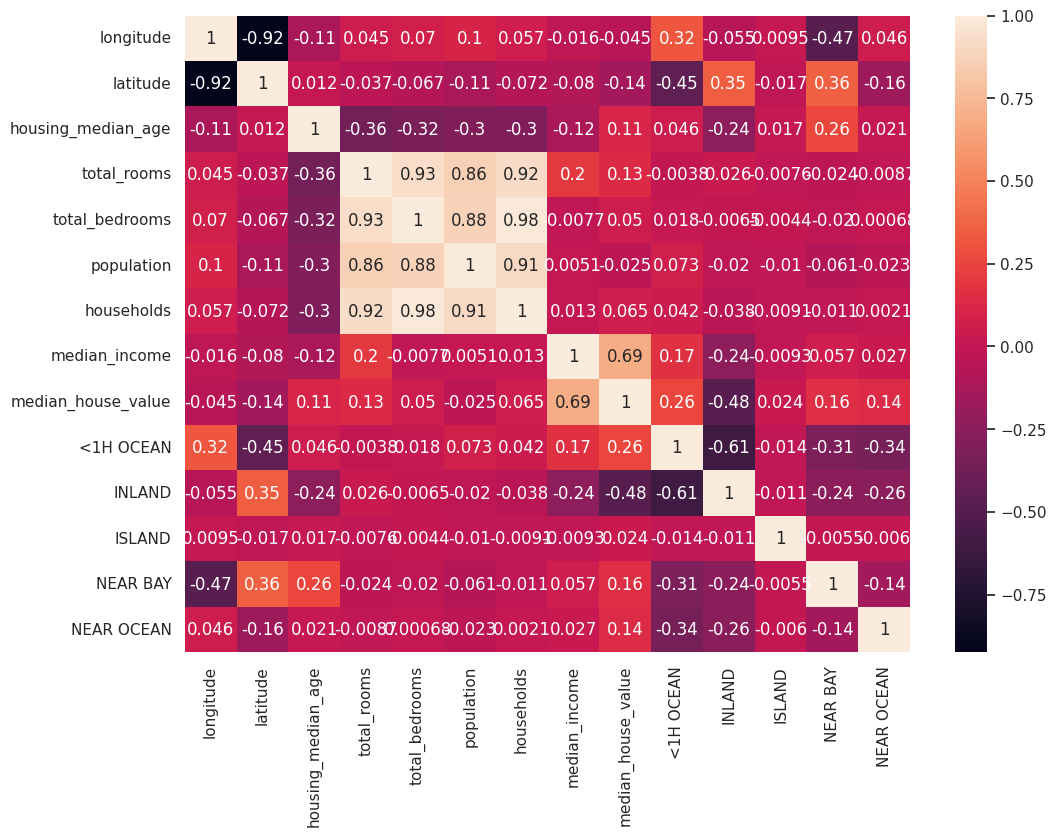

In [58]:
sb.set(rc={'figure.figsize':(11.7,8.27)})
sb.heatmap(datos_na.corr(), annot=True)

In [59]:
#aqui nos centramos en el dato que realmente nos interesa el cual es el precio de las casas
datos_na.corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688355
<1H OCEAN,0.257614
NEAR BAY,0.160526
NEAR OCEAN,0.140378
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
ISLAND,0.023525


aqui podemos marcar la continuacion del codigo ya que necesitamos los datos para continuar, en este punto estamos usando el codigo parra que nos de una grafica de los ingresos que marca que mientras mas ingresos hay el valor de las casas aumenta considerablemente

<Axes: xlabel='median_house_value', ylabel='median_income'>

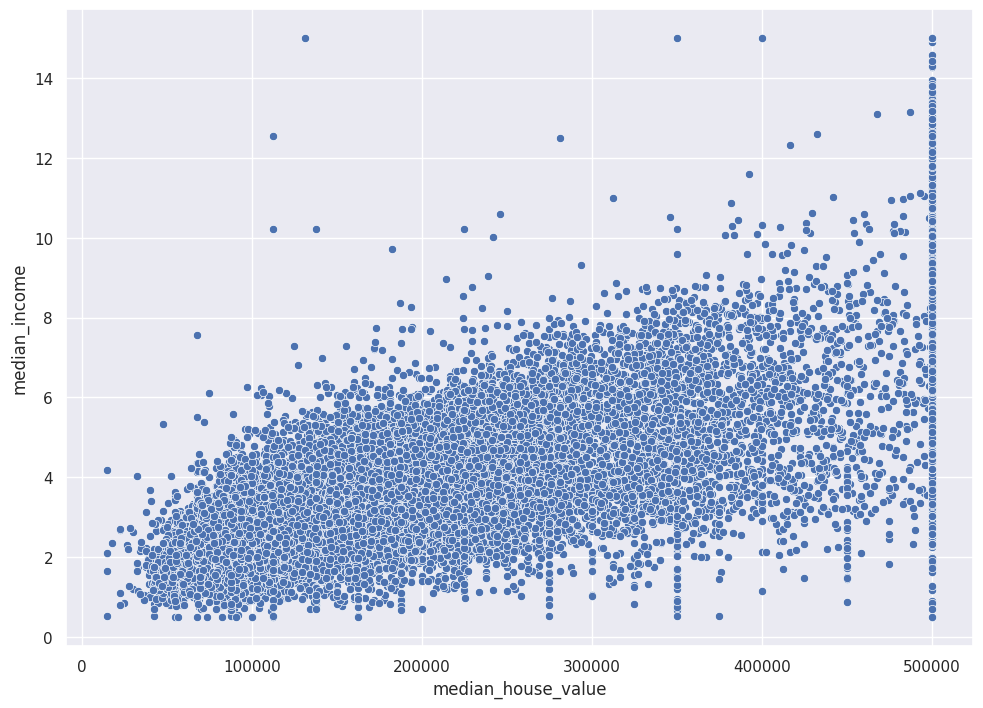

In [60]:
sb.scatterplot(x=datos_na["median_house_value"], y= datos_na["median_income"])

aqui podemos crear otra variable que al correr de nuevo el codigo se ve reflejada ahi mismo en la tabla

In [61]:
datos_na["bedroom_ratio"] = datos_na["total_bedrooms"]/datos_na["total_rooms"]

<Axes: >

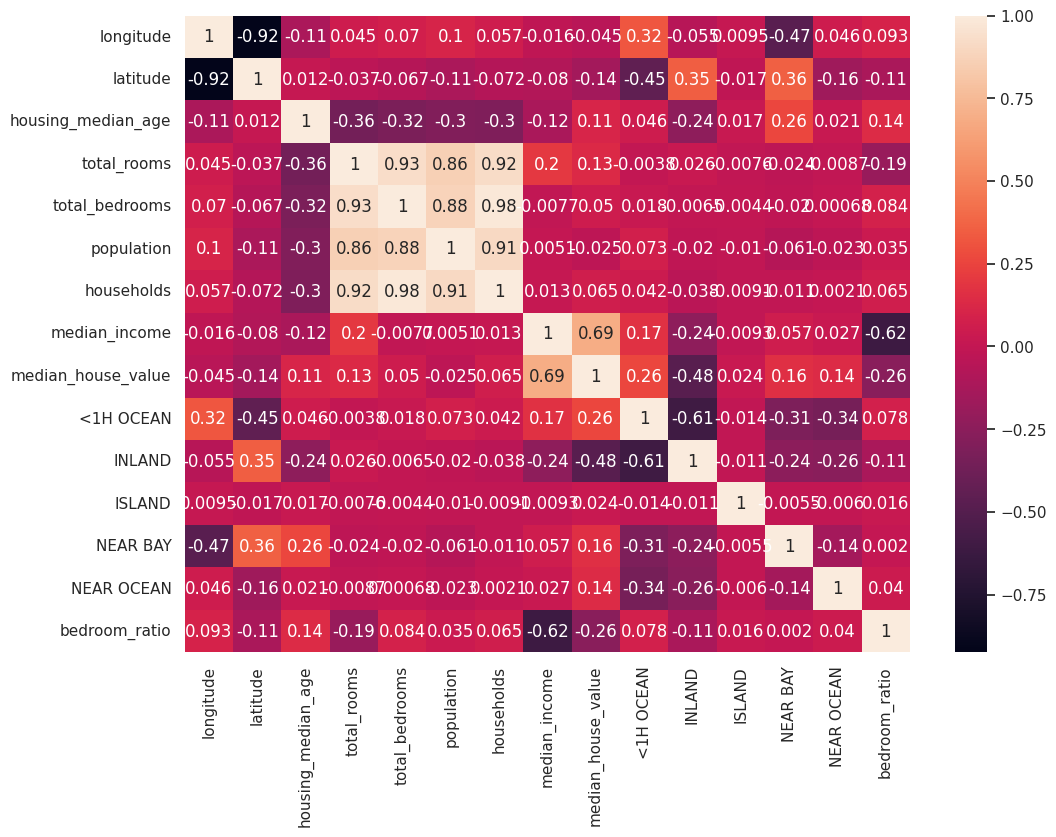

In [62]:
sb.set(rc={'figure.figsize':(11.7,8.27)})
sb.heatmap(datos_na.corr(), annot=True)

apartir de aqui separamos las caracteristicas de la etiqueta

In [63]:
x = datos_na.drop("median_house_value", axis=1)
y = datos_na["median_house_value"]

vamos a separar los datos en 2 partes el conjunto de entrenamiento y el conjunto de prueba

In [64]:
from sklearn.model_selection import train_test_split

x_ent, x_pru, y_ent,y_pru = train_test_split(x, y, train_size=.2)

In [65]:
from sklearn.linear_model import LinearRegression

modelo=LinearRegression()

In [66]:
modelo.fit(x_ent, y_ent)

LinearRegression()

In [68]:
predicciones = modelo.predict(x_pru)

creamos varias variables que nos permitan hacer ajustes dentro de la informacion que tenemos

In [72]:
comparativa = {"prediccion": predicciones, "valor real": y_pru}
pd.DataFrame(comparativa)
#podemos mostrar aqui lo que predijo y su valor real

,prediccion,valor real
20371,280448.087623,313800.0
9750,326963.850575,244900.0
2296,82633.480633,74500.0
326,129307.796085,84700.0
10790,210326.740360,407000.0
...,...,...
18584,160686.507264,178400.0
16311,183705.077500,129200.0
5095,144595.712635,99800.0
12136,110425.275796,244400.0


aqui voy a realizar pruebas para saber si no hay sobre ajustes en los datos

In [73]:
print(modelo.score(x_ent, y_ent))
print(modelo.score(x_pru, y_pru))

0.6524888861055756
0.6502347563986892


In [74]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_pru, predicciones)

In [77]:
mse
#hacemos comprovacion de errores lo que hace es elevar
#al cuadrado los errores para que los negativos se vuelvan positivos
#y los errores se noten mas

4644550259.169274

In [79]:
rmse = np.sqrt(mse)
#aqui obtenemos la raiz cuadrada del numero anterior

In [80]:
rmse

np.float64(68150.93733155307)

usamos el escalamiento para hacer que la distanicia entre los datos no sea tanta Y en ningun momento le de peso mas peso a otros datos

In [82]:
datos_na.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedroom_ratio
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.213039
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.100000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.203162
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_ent_esc = scaler.fit_transform(x_ent)
x_pru_esc = scaler.transform(x_pru)

In [87]:
x_ent

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
19657,-120.84,37.48,10.0,2874.0,612.0,1960.0,596.0,2.7381,False,True,False,False,False,0.212944
4060,-118.45,34.16,22.0,7828.0,2038.0,3303.0,1922.0,3.6171,True,False,False,False,False,0.260347
14423,-117.23,32.81,28.0,1508.0,263.0,996.0,267.0,3.8026,False,False,False,False,True,0.174403
7743,-118.15,33.93,25.0,1948.0,433.0,1128.0,429.0,3.7614,True,False,False,False,False,0.222279
14952,-116.95,32.73,17.0,1635.0,272.0,960.0,279.0,5.2671,True,False,False,False,False,0.166361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15753,-122.45,37.77,52.0,2296.0,509.0,1039.0,472.0,4.1417,False,False,False,True,False,0.221690
4886,-118.26,34.02,48.0,1465.0,440.0,1859.0,400.0,1.3134,True,False,False,False,False,0.300341
7658,-118.21,33.84,28.0,822.0,205.0,627.0,192.0,3.4583,True,False,False,False,False,0.249392
13699,-117.20,34.12,24.0,3532.0,618.0,1681.0,590.0,3.5000,False,True,False,False,False,0.174972


In [90]:
pd.DataFrame(x_ent_esc)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.650622,0.882123,-1.464300,0.106910,0.175411,0.489938,0.266799,-0.616078,-0.905116,1.468064,0.0,-0.328051,-0.396045,0.003595
1,0.549140,-0.677669,-0.508618,2.364710,3.542474,1.721767,3.808037,-0.148334,1.104831,-0.681169,0.0,-0.328051,-0.396045,0.833725
2,1.161570,-1.311922,-0.030776,-0.515649,-0.648645,-0.394265,-0.611834,-0.049624,-0.905116,-0.681169,0.0,-0.328051,2.524966,-0.671321
3,0.699737,-0.785727,-0.269697,-0.315118,-0.247242,-0.273192,-0.179194,-0.071548,1.104831,-0.681169,0.0,-0.328051,-0.396045,0.167079
4,1.302128,-1.349507,-0.906819,-0.457768,-0.627395,-0.427285,-0.579787,0.729683,1.104831,-0.681169,0.0,-0.328051,-0.396045,-0.812157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081,-1.458829,1.018370,1.880589,-0.156516,-0.067792,-0.354824,-0.064358,0.130822,-0.905116,-0.681169,0.0,3.048310,-0.396045,0.156758
4082,0.644518,-0.743443,1.562028,-0.535247,-0.230714,0.397298,-0.256642,-1.374205,1.104831,-0.681169,0.0,-0.328051,-0.396045,1.534092
4083,0.669618,-0.828010,-0.030776,-0.828296,-0.785595,-0.732720,-0.812130,-0.232837,1.104831,-0.681169,0.0,-0.328051,-0.396045,0.641869
4084,1.176630,-0.696462,-0.349337,0.406795,0.189579,0.234032,0.250775,-0.210647,-0.905116,1.468064,0.0,-0.328051,-0.396045,-0.661365
